# Module 1 - Revisiting Basics of Keplerian Motion

...or introduction to orbital mechanics if this is your first rodeo ;)

This module revisits the fundamentals of unperturbed Keplerian spacecraft motion. The material is presented as a review and therefore moves quickly, with the assumption that the basic concepts of particle kinematics and orbital mechanics have been encountered before.

The first part of the module returns to particle kinematics and the description of motion using position, velocity, and acceleration vectors. This provides the mathematical foundation needed to describe spacecraft motion consistently before introducing the orbital dynamics.

The remainder of the module reviews the classical two-body problem, beginning with conic sections and progressing to Kepler's equation and the classical orbital elements. Together, these concepts provide the baseline description of ideal spacecraft motion before perturbations and relative-motion effects are introduced later in the course.

**<ins>Learning Objectives</ins>**

- Review the fundamental relationships used in particle kinematics.
- Describe Keplerian orbits using conic sections.
- Apply Kepler's equation to determine spacecraft position as a function of time.
- Describe an orbit using the classical orbital elements.
- Establish the two-body Keplerian model that will be used as the reference for later relative-motion analysis.

**<ins>Content</ins>**
- Particle kinematics fundamentals
- Conic sections and Keplerian orbits
- Kepler's equation and orbital time propagation
- Classical orbital elements

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1.1 - Fundamentals of Particle Kinematics

## 1.1.1 - Vectors, Reference Frames, and Coordinate Representation

Before describing motion, we first need to be precise about **what is being measured** and **relative to what it is being measured**.

A **scalar** is a physical quantity that can be completely described by a single numerical value and its associated units. Scalars have magnitude but no direction. Examples include mass, temperature, time, and distance.

A **vector**, on the other hand, contains both magnitude and direction. Position, velocity, acceleration, and force are all vector quantities.

Consider the statement:

> An object is located $5\,\text{m}$ away.

This statement is incomplete if we want to describe the object's position. We must also ask:

- $5\,\text{m}$ away from **what point**?
- In **what direction**?

The reference point defines the **origin** from which the position is measured. Together with a set of basis directions, this defines a **reference frame**.

**<ins>Reference Frames and Coordinate Representation</ins>**

Consider a reference frame $N$ with three orthogonal basis vectors

$$
\mathcal{N} =
\left\{
\hat{\mathbf n}_1,
\hat{\mathbf n}_2,
\hat{\mathbf n}_3
\right\}.
$$

A physical vector $\mathbf r$ can be constructed from these basis vectors as

$$
\mathbf r = r_1\hat{\mathbf n}_1 + r_2\hat{\mathbf n}_2 + r_3\hat{\mathbf n}_3.
$$

The scalars $r_1$, $r_2$, and $r_3$ tell us how much of $\mathbf r$ lies along each basis direction. These values are called the **components** of the vector in frame $N$.

We can collect these components into a column vector,

$$
[\mathbf r]_N =
\begin{bmatrix}
r_1\\
r_2\\
r_3
\end{bmatrix}.
$$

This is the **coordinate representation** of $\mathbf r$ in frame $N$.

It is important to distinguish between the two:

$$
\boxed{
\mathbf r
\quad\text{is the geometric vector}
}
$$

while

$$
\boxed{
[\mathbf r]_N
\quad\text{is its numerical representation in frame }N
}
$$

If another reference frame $B$ is used, the same physical vector may have a different coordinate representation,

$$
[\mathbf r]_B \neq [\mathbf r]_N,
$$

even though $\mathbf r$ itself has not changed.

In numerical work, we usually store and manipulate these **vector components** and transform them from one frame to another using a **Direction Cosine Matrices (DCMs)**,

$$
[\mathbf r]_B = [BN] [\mathbf r]_N
$$

where $[BN]$ is the DCM decribing the orientation of the $B$-frame to the $N$-frame and provides a means to map a vector in $N$-frame to the $B$-frame. Please refer to the course notes in the first specialization, specifically the first course, where an extensive treatment is done to describe DCMs and the equivalent attitude representations to decribe orientation and frame conversions.

**<ins>Inertial Reference Frames</ins>**

Newton's laws take their simplest form when motion is described relative to an **inertial reference frame**.

An inertial frame is a frame whose origin is not accelerating and whose axes are not rotating relative to inertial space. A frame may translate at constant velocity and still be inertial.

In such a frame, the acceleration obtained by differentiating the position vector twice corresponds directly to the acceleration used in Newton's second law,

$$
\mathbf F = m\ddot{\mathbf r}.
$$

If the reference frame itself accelerates or rotates, additional kinematic terms appear. Understanding how vector derivatives change between different reference frames will therefore become important when describing spacecraft motion.

In [6]:
# ---------------------------------------------------------------------------------------
# Vector and frame notation
#
# In numerical code, explicitly include the reference frame in the variable name:
#
#     <vector>_<frame> = np.array([...])
#
# Example:
#
#     r_N
#
# means:
#     "the components of the geometric vector r expressed in reference frame N."
#
# For direction cosine matrices:
#
#     C_BN
#
# maps vector components from frame N into frame B:
#
#     r_B = C_BN @ r_N
#
# Unless explicitly stated otherwise, coordinate transformations in this notebook
# are PASSIVE:
#
#     - The physical vector does not rotate.
#     - The reference frame / basis changes.
#     - Only the coordinate representation changes.
#
# Active rotations will be explicitly identified as rotations of the geometric vector.
# ---------------------------------------------------------------------------------------

# Vector expressed in reference frame N
r_N = np.array([4.0, 3.0])

# Frame B is rotated counter-clockwise relative to frame N
theta = np.deg2rad(35.0)

c = np.cos(theta)
s = np.sin(theta)

# Passive transformation: N-components -> B-components
C_BN = np.array([
    [ c,  s],
    [-s,  c]
])

r_B = C_BN @ r_N

# Active rotation: rotate the physical vector by +theta while keeping frame N fixed
R_theta = np.array([
    [c, -s],
    [s,  c]
])

r_rotated_N = R_theta @ r_N

print(f"Vector components in frame N: {r_N}")
print(f"Vector components in frame B: {r_B}")
print(f"Actively rotated vector in frame N: {r_rotated_N}")

print(f"\nMagnitude in frame N: {np.linalg.norm(r_N):.3f}")
print(f"Magnitude in frame B: {np.linalg.norm(r_B):.3f}")
print(f"Magnitude after active rotation: {np.linalg.norm(r_rotated_N):.3f}")

Vector components in frame N: [4. 3.]
Vector components in frame B: [4.99733749 0.16315039]
Actively rotated vector in frame N: [1.55587887 4.75176188]

Magnitude in frame N: 5.000
Magnitude in frame B: 5.000
Magnitude after active rotation: 5.000


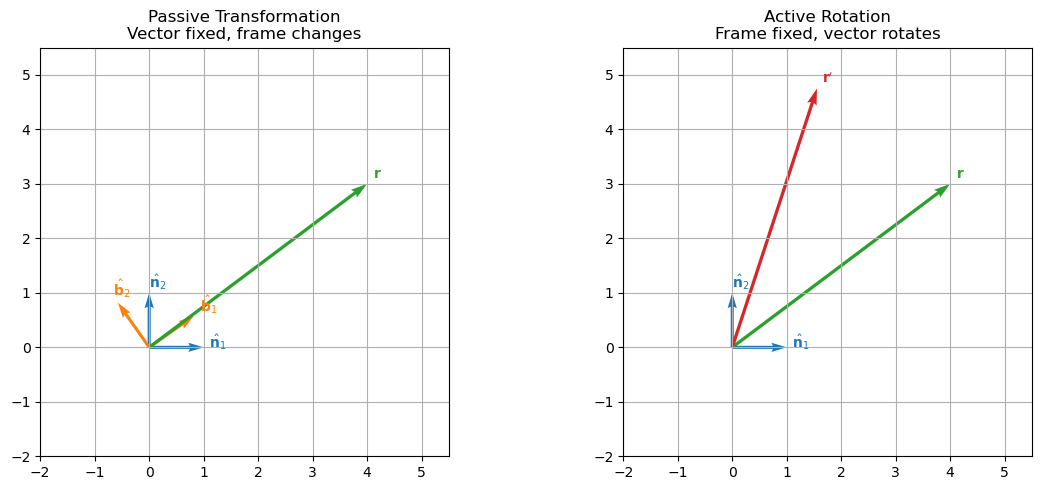

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Basis vectors of frame N
n1_N = np.array([1.0, 0.0])
n2_N = np.array([0.0, 1.0])

# Basis vectors of frame B expressed in frame N
b1_N = np.array([ c, s])
b2_N = np.array([-s, c])

# Passive transformation
ax = axes[0]

ax.quiver(
    0, 0, *n1_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:blue"
)
ax.quiver(
    0, 0, *n2_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:blue"
)

ax.quiver(
    0, 0, *b1_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:orange"
)
ax.quiver(
    0, 0, *b2_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:orange"
)

ax.quiver(
    0, 0, *r_N,
    angles="xy", scale_units="xy", scale=1,
    width=0.008,
    color="tab:green"
)

ax.text(1.1, 0.0, r"$\hat{\mathbf{n}}_1$", color="tab:blue")
ax.text(0.0, 1.1, r"$\hat{\mathbf{n}}_2$", color="tab:blue")
ax.text(*(1.15 * b1_N), r"$\hat{\mathbf{b}}_1$", color="tab:orange")
ax.text(*(1.15 * b2_N), r"$\hat{\mathbf{b}}_2$", color="tab:orange")
ax.text(
    r_N[0] + 0.1,
    r_N[1] + 0.1,
    r"$\mathbf{r}$",
    color="tab:green"
)

ax.set_title("Passive Transformation\nVector fixed, frame changes")
ax.set_xlim(-2, 5.5)
ax.set_ylim(-2, 5.5)
ax.set_aspect("equal")
ax.grid()


# Active rotation
ax = axes[1]

ax.quiver(
    0, 0, *n1_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:blue"
)
ax.quiver(
    0, 0, *n2_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:blue"
)

ax.quiver(
    0, 0, *r_N,
    angles="xy", scale_units="xy", scale=1,
    width=0.008,
    color="tab:green"
)

ax.quiver(
    0, 0, *r_rotated_N,
    angles="xy", scale_units="xy", scale=1,
    width=0.008,
    color="tab:red"
)

ax.text(1.1, 0.0, r"$\hat{\mathbf{n}}_1$", color="tab:blue")
ax.text(0.0, 1.1, r"$\hat{\mathbf{n}}_2$", color="tab:blue")

ax.text(
    r_N[0] + 0.1,
    r_N[1] + 0.1,
    r"$\mathbf{r}$",
    color="tab:green"
)

ax.text(
    r_rotated_N[0] + 0.1,
    r_rotated_N[1] + 0.1,
    r"$\mathbf{r}^{\prime}$",
    color="tab:red"
)

ax.set_title("Active Rotation\nFrame fixed, vector rotates")
ax.set_xlim(-2, 5.5)
ax.set_ylim(-2, 5.5)
ax.set_aspect("equal")
ax.grid()

plt.tight_layout()
plt.show()

**<ins>Intuitive Summary</ins>**

A vector is a physical geometric quantity. What changes from one reference frame to another is not the vector itself, but the **numbers used to describe it**.

The reference frame provides the origin and basis directions. Once a frame is chosen, the vector can be written through its components in that frame,

$$
[\mathbf r]_N.
$$

If we change the frame from $N$ to $B$ while keeping the physical vector fixed, we perform a **passive transformation**,

$$
[\mathbf r]_B = [C_{BN}][\mathbf r]_N.
$$

The vector has not moved. We have simply changed the coordinate system used to describe it.

An **active transformation** does the opposite. The reference frame stays fixed while the physical vector itself is rotated,

$$
[\mathbf r']_N = [R(\theta)][\mathbf r]_N.
$$

The easiest way to remember the difference is therefore

$$
\boxed{
\text{Passive: move the frame, keep the vector fixed}
}
$$

$$
\boxed{
\text{Active: keep the frame fixed, move the vector}
}
$$

For the same relative rotation, these operations act in opposite directions. Therefore,

$$
[C_{BN}] = [R(\theta)]^{-1} = [R(\theta)]^T.
$$

The transpose appears because rotation matrices are orthogonal, so reversing a rotation is equivalent to transposing its matrix.

Throughout these notes, transformations between reference frames will be treated as **passive transformations unless explicitly stated otherwise**.

With the ideas of vectors, frames, and coordinate representation established, the next question is:

> What happens when these vectors change with time?

This leads naturally to position, velocity, and acceleration.

## 1.1.2 - Position, Velocity and Acceleration

## 1.1.3 - Newton's Laws and Inertial Frames

## 1.1.4 - Rotating Frames and Transport Theorem

## 1.1.5 - Visual Example

# 1.2 - Keplerian Motion

## 1.2.1 - The Two-Body Problem 

## 1.2.2 - Fundamental Integrals of Orbital Motion

## 1.2.3 - Orbit Geometry and Conic Sections

## 1.2.4 - Kepler's Laws

## 1.2.5 - Orbital Motion as a Function of Time

## 1.2.6 - Classical Orbital Elements 

## 1.2.7 - Coordinate Transformations 